In [12]:
using Pkg;

Pkg.add(["Kneedle"])

using ITensors, ITensorMPS, Plots
include("../../data/params.jl")
include("../../data/helpers/saving.jl")
include("../schmidt_spectra/get_spectrum.jl")
include("../schmidt_spectra/deviation/deviation.jl")

   Resolving package versions...
  No Changes to `~/dev/uni/msciproject/Project.toml`
  No Changes to `~/dev/uni/msciproject/Manifest.toml`
   Resolving package versions...
  No Changes to `~/dev/uni/msciproject/Project.toml`
  No Changes to `~/dev/uni/msciproject/Manifest.toml`


find_deviation_idx (generic function with 1 method)

In [76]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 10,
                    "MAX_BOND_DIM" => 1000,
                    "ACC" => 10^-16
                    )

N = 60
σ = 0.001

run_params_cln = Dict{String, Any}(
    "N" => N,
    "σ" => 0.00
)

run_params_dis = Dict{String, Any}(
    "N" => N,
    "σ" => σ
)

CURRENT_DIR = @__DIR__
FP = extract_filename_from_system_params(system_params)
MPS_FP = joinpath(CURRENT_DIR, "../../data/storage/perturb_sigma_$(σ)_$(FP).hd5")
matches_cln = find_runs_by_params(MPS_FP, run_params_cln; load_psi=true, instance_selection=:latest)
matches_dis = find_runs_by_params(MPS_FP, run_params_dis; load_psi=true, instance_selection=:latest)

psi_cln = matches_cln[1].psi
psi_dis = matches_dis[1].psi

print(maxlinkdim(psi_cln), maxlinkdim(psi_dis))

65567

In [14]:
spec_cln = get_squared_sorted_schmidt_spectrum_from_mps(psi_cln)
spec_dis = get_squared_sorted_schmidt_spectrum_from_mps(psi_dis)

1000-element Vector{Float64}:
 0.23620550531235704
 0.23620550529066692
 0.16114442026962617
 0.16114442022394407
 0.07446227774118741
 0.07446227770587956
 0.02295208527933095
 0.022952085260371298
 0.004601259774528628
 0.0046012597701756055
 ⋮
 1.1060434413562197e-14
 1.1053592118319309e-14
 1.1015216812628377e-14
 1.0963833955117799e-14
 1.0932820381195382e-14
 1.0040040674406015e-14
 9.954595078596805e-15
 9.297838556653365e-15
 9.251723097623153e-15

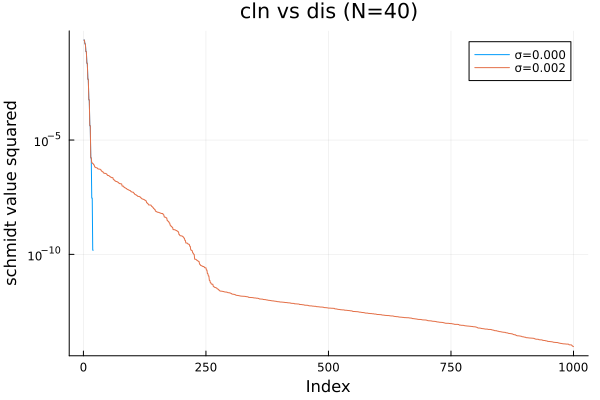

"/Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/clean_vs_disordered_N=40_sigma=0.002_acc=1.0e-16.png"

In [15]:
p_cln_vs_dis = plot(title="cln vs dis (N=40)", yscale=:log10, xlabel="Index", ylabel="schmidt value squared")

plot!(p_cln_vs_dis, 1:length(spec_cln), spec_cln, label="σ=0.000")
plot!(p_cln_vs_dis, 1:length(spec_dis), spec_dis, label="σ=0.002")

display(p_cln_vs_dis)
savefig(p_cln_vs_dis, joinpath(CURRENT_DIR, "clean_vs_disordered_N=40_sigma=0.002_acc=1.0e-16.png"))

In [16]:
ξ = inner(psi_cln, psi_dis)

0.9999730454595684

In [17]:
psi_r = psi_dis - ξ * psi_cln
normalize!(psi_r)

40-element MPS:
 ((dim=2|id=204|"S=1/2,Site,n=1") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=4|id=151|"Link,l=1") <Out>
 1: QN("Sz",-1) => 2
 2: QN("Sz",1) => 2)
 ((dim=2|id=121|"S=1/2,Site,n=2") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=7|id=26|"Link,l=2") <Out>
 1: QN("Sz",-2) => 2
 2: QN("Sz",0) => 3
 3: QN("Sz",2) => 2, (dim=4|id=151|"Link,l=1") <In>
 1: QN("Sz",-1) => 2
 2: QN("Sz",1) => 2)
 ((dim=2|id=310|"S=1/2,Site,n=3") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=12|id=283|"Link,l=3") <Out>
 1: QN("Sz",-3) => 2
 2: QN("Sz",-1) => 4
 3: QN("Sz",1) => 4
 4: QN("Sz",3) => 2, (dim=7|id=26|"Link,l=2") <In>
 1: QN("Sz",-2) => 2
 2: QN("Sz",0) => 3
 3: QN("Sz",2) => 2)
 ((dim=2|id=750|"S=1/2,Site,n=4") <Out>
 1: QN("Sz",1) => 1
 2: QN("Sz",-1) => 1, (dim=21|id=817|"Link,l=4") <Out>
 1: QN("Sz",-4) => 2
 2: QN("Sz",-2) => 5
 3: QN("Sz",0) => 7
 4: QN("Sz",2) => 5
 5: QN("Sz",4) => 2, (dim=12|id=283|"Link,l=3") <In>
 1: QN("Sz",-3) => 2
 2: QN("Sz",-1) => 

┌ Info: Sum: 1.0000000000000004
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_W6sZmlsZQ==.jl:3


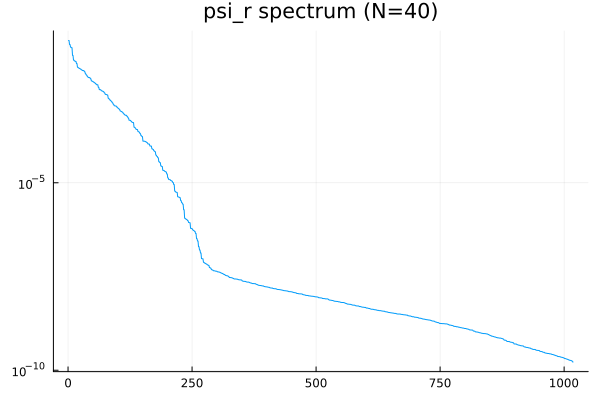

In [18]:
spec_r = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)

@info "Sum: $(sum(spec_r))"

p3 = plot(1:length(spec_r), spec_r, title="psi_r spectrum (N=40)",yscale=:log10, legend=false)

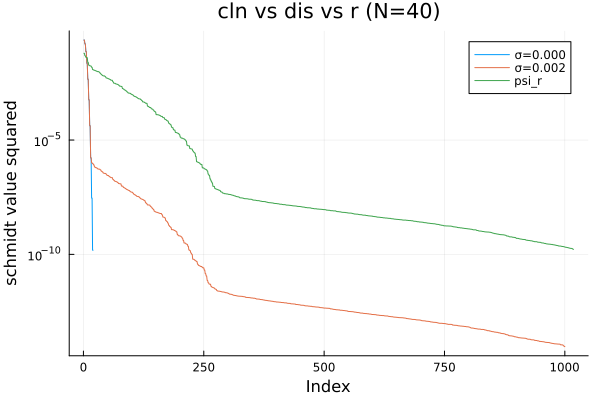

"/Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/clean_vs_disordered_N=40_sigma=0.002_acc=1.0e-16.png"

In [19]:
p_cln_vs_dis_vs_r = plot(title="cln vs dis vs r (N=40)", yscale=:log10, xlabel="Index", ylabel="schmidt value squared")

plot!(p_cln_vs_dis_vs_r, 1:length(spec_cln), spec_cln, label="σ=0.000")
plot!(p_cln_vs_dis_vs_r, 1:length(spec_dis), spec_dis, label="σ=0.002")
plot!(p_cln_vs_dis_vs_r, 1:length(spec_r), spec_r, label="psi_r")

display(p_cln_vs_dis_vs_r)
savefig(p_cln_vs_dis_vs_r, joinpath(CURRENT_DIR, "clean_vs_disordered_N=40_sigma=0.002_acc=1.0e-16.png"))

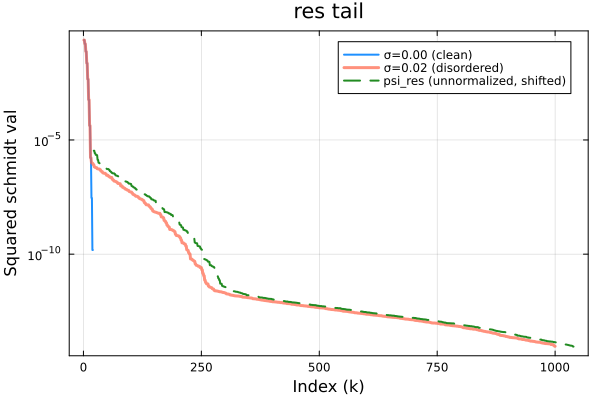

cln_res: -1.9857975940701378e-15, dis_res: 5.390835430257261e-5, cln_dis:0.9999730454595701
sum of dis_cln + dis_res (ξ + √1-ξ^2): 1.0000269538138726


In [47]:
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 10,
                    "MAX_BOND_DIM" => 1000,
                    "ACC" => 10^-16
                    )

run_params_cln = Dict{String, Any}(
    "N" => 40,
    "σ" => 0.00
)

run_params_dis = Dict{String, Any}(
    "N" => 40,
    "σ" => 0.02
)

CURRENT_DIR = @__DIR__
FP = extract_filename_from_system_params(system_params)
MPS_FP = joinpath(CURRENT_DIR, "../../data/storage/perturb_$(FP).hd5")
matches_cln = find_runs_by_params(MPS_FP, run_params_cln; load_psi=true, instance_selection=:latest)
matches_dis = find_runs_by_params(MPS_FP, run_params_dis; load_psi=true, instance_selection=:latest)

psi_cln = matches_cln[1].psi
psi_dis = matches_dis[1].psi

ξ = inner(psi_cln, psi_dis)
psi_res = psi_dis - ξ * psi_cln
# do not normalise, want to try overlaying

χ_cln = maxlinkdim(psi_cln)

spec_cln = get_squared_sorted_schmidt_spectrum_from_mps(psi_cln)
spec_dis = get_squared_sorted_schmidt_spectrum_from_mps(psi_dis)
spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)

overlap_cln_res = inner(psi_cln, psi_res)
overlap_dis_res = inner(psi_dis, psi_res)
println("cln_res: ", overlap_cln_res, ", dis_res: ", overlap_dis_res, ", cln_dis:", ξ)
println("sum of dis_cln + dis_res (ξ + √1-ξ^2): ", ξ + overlap_dis_res)


idx_cln = 1:length(spec_cln)
idx_dis = 1:length(spec_dis)

# Create the shifted x-axis indices for the residual spectrum
# We shift it to the right by χ_cln
idx_res_shifted = (1:length(spec_res)) .+ χ_cln

# Initialize the plot with a logarithmic y-axis
plt = plot(yaxis=:log10,
           title="res tail",
           xlabel="Index (k)",
           ylabel="Squared schmidt val",
           legend=:topright,
           grid=true,
           framestyle=:box)

# Plot the three spectra
plot!(plt, idx_cln, spec_cln, label="σ=0.00 (clean)", linewidth=2, color=:dodgerblue)
plot!(plt, idx_dis, spec_dis, label="σ=$(run_params_dis["σ"]) (disordered)", linewidth=3, color=:tomato, alpha=0.7)

# Plot the residual state as a dashed line so we can see if it overlays the solid red line
plot!(plt, idx_res_shifted, spec_res, label="psi_res (unnormalized, shifted)", linewidth=2, color=:forestgreen, linestyle=:dash)

# Display the plot
display(plt)


# With disorder

In [20]:
# we can load in a set of data points
sigma_vals = 0.0001:0.00005:0.002
N = 40
system_params = Dict{String,Any}(
                    "J" => -1.0,
                    "Δ" => -1.0,
                    "μ" => 1.0,
                    "NUM_SWEEPS" => 10,
                    "MAX_BOND_DIM" => 1000,
                    "ACC" => 10^-16
                    )

CURRENT_DIR = @__DIR__
base_fp = extract_filename_from_system_params(system_params)

sigma_to_psi = Dict{Float64, Tuple{MPS, MPS}}()
# stores (cln, dis)

for sigma in sigma_vals
    rp_cln = Dict{String, Any}(
        "N" => N,
        "σ" => 0.00
    )
    rp_dis = Dict{String, Any}(
        "N" => N,
        "σ" => sigma
    )
    fp = joinpath(CURRENT_DIR, "../../data/storage/perturb_sigma_$(sigma)_$(FP).hd5")
    cln = find_runs_by_params(fp, rp_cln; load_psi=true, instance_selection=:latest)[1].psi
    dis = find_runs_by_params(fp, rp_dis; load_psi=true, instance_selection=:latest)[1].psi

    sigma_to_psi[sigma] = (cln, dis)
end

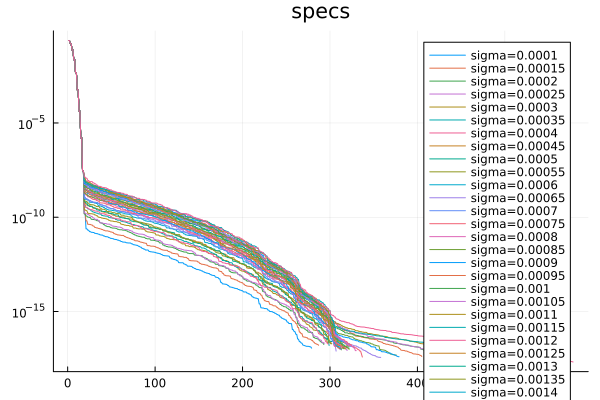

In [21]:
# lets just plot all of these on the graph to see what they look like

sorted_pairs = sort(collect(sigma_to_psi), by=x->x[1])

p_ss = plot(title="specs", yscale=:log10)

for (sigma, (cln, dis)) in sorted_pairs
    # plot!(1:length(cln), cln, label="cln sigma=$sigma")
    dis_spec = get_squared_sorted_schmidt_spectrum_from_mps(dis)
    plot!(1:length(dis_spec), dis_spec, label="sigma=$sigma")
end

display(p_ss)



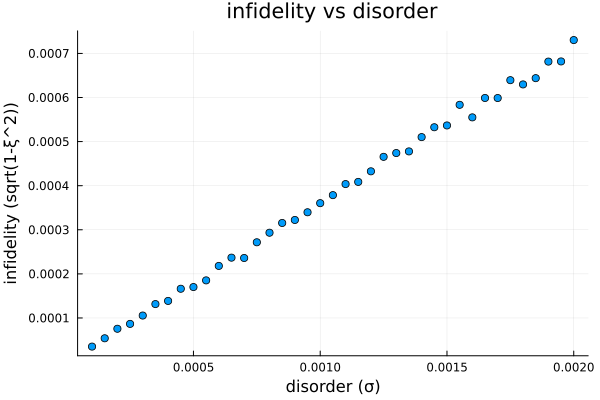

In [51]:
# now calc inner vs sigma^2 (variance)
infidelity(a, b) = sqrt(1 - abs(inner(a, b))^2)

fidelities = []
sigmas = []
for (sigma, (cln, dis)) in sorted_pairs
    fid = infidelity(cln, dis)
    push!(sigmas, sigma)
    push!(fidelities, fid)
end

p_overlap = scatter(sigmas, fidelities, title="infidelity vs disorder", xlabel="disorder (σ)", ylabel="infidelity (sqrt(1-ξ^2))", legend=false)

In [23]:
function get_psi_r(cln, dis; normalize=true)
    ξ = inner(cln, dis)
    psi_r = dis - ξ * cln
    return normalize ? normalize!(psi_r) : psi_r
end


get_psi_r (generic function with 1 method)

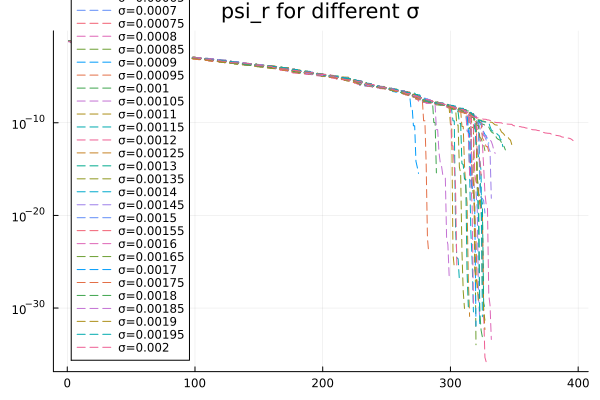

In [24]:

p_psi_rs = plot(title="psi_r for different σ", yscale=:log10, legend=:bottomleft)

for (sigma, (cln, dis)) in sorted_pairs
    pr = get_psi_r(cln, dis; normalize=true)
    s = get_squared_sorted_schmidt_spectrum_from_mps(pr)
    plot!(p_psi_rs, 1:length(s), s, label="σ=$sigma", linestyle=:dash)
end

display(p_psi_rs)


In [25]:

sigma_to_psis=Dict{Float64, Tuple{Vector{MPS}, Vector{MPS}}}()
# looks like sigma => (cln_mpss, dis_mpss)

for sigma in sigma_vals
    rp_cln = Dict{String, Any}(
        "N" => N,
        "σ" => 0.00
    )
    rp_dis = Dict{String, Any}(
        "N" => N,
        "σ" => sigma
    )
    fp = joinpath(CURRENT_DIR, "../../data/storage/perturb_sigma_$(sigma)_$(FP).hd5")
    cln_rns = find_runs_by_params(fp, rp_cln; load_psi=true, instance_selection=:all)
    dis_rns = find_runs_by_params(fp, rp_dis; load_psi=true, instance_selection=:all)

    cln_psis = [c.psi for c in cln_rns if c.psi != nothing]
    dis_psis = [d.psi for d in dis_rns if d.psi != nothing]

    sigma_to_psis[sigma] = (cln_psis, dis_psis)
end

┌ Info: σ = 0.0001 had 6 instances, with mean: 3.510885703110328e-5, error: 1.836971991918768e-7
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X21sZmlsZQ==.jl:17
┌ Info: σ = 0.00015 had 4 instances, with mean: 5.3854961492514245e-5, error: 3.72364870219553e-7
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X21sZmlsZQ==.jl:17
┌ Info: σ = 0.0002 had 4 instances, with mean: 7.2237257990838e-5, error: 1.0965222451303435e-6
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X21sZmlsZQ==.jl:17
┌ Info: σ = 0.00025 had 4 instances, with mean: 8.666005252553171e-5, error: 1.2139496205616018e-6
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X21sZmlsZQ==.jl:17
┌ Info: σ = 0.0003 had 4 instances, with mean:

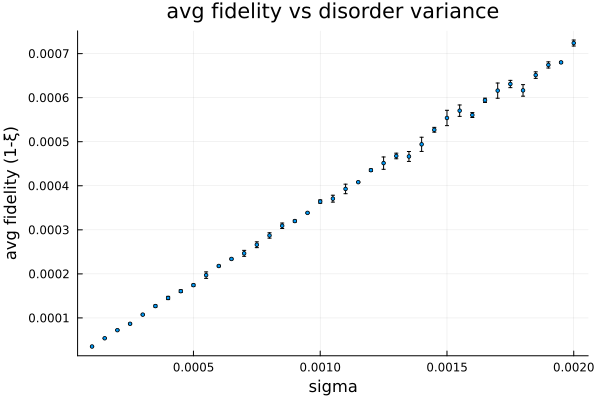

In [77]:
using Statistics, StatsBase

sorted_pairs_pl = sort(collect(sigma_to_psis), by=x->x[1])

avg_fidelities = Float64[]
err_fidelities = Float64[]
sigma_vars = Float64[]

for (sigma, (clns, diss)) in sorted_pairs_pl
    # calculate fidelity for every instance pair at this sigma
    fids = [infidelity(c, d) for (c, d) in zip(clns, diss)]

    avg_f = mean(fids)
    err_f = sem(fids)
    if isnan(err_f) err_f = 0 end

    @info "σ = $sigma had $(length(fids)) instances, with mean: $avg_f, error: $err_f"

    push!(avg_fidelities, avg_f)
    push!(err_fidelities, err_f)
    push!(sigma_vars, sigma)

end

p_fid = scatter(sigma_vars, avg_fidelities,
                yerror=err_fidelities,
                title="avg fidelity vs disorder variance",
                xlabel="sigma",
                ylabel="avg fidelity (1-ξ)",
                legend=false,
                markersize=2,
                markerstrokewidth=1)


In [55]:
using GLM, DataFrames

err_fidelities_clean = replace(err_fidelities, NaN => 0.0)

weights = [e > 0 ? 1/e^2 : 1.0 for e in err_fidelities_clean]

valid_weights = [1/e^2 for e in err_fidelities_clean if e > 0]
default_weight = isempty(valid_weights) ? 1.0 : median(valid_weights)

final_weights = [e > 0 ? 1/e^2 : default_weight for e in err_fidelities_clean]

df = DataFrame(X = sigma_vars, Y = avg_fidelities)

# fit (and force through 0 for this)
model = lm(@formula(Y ~ 0 + X), df, wts=final_weights)

# Extract results
gradient = coef(model)[1]
grad_err = stderror(model)[1]

println("Gradient: $gradient ± $grad_err")

Gradient: 0.35482367039597684 ± 4.2690403429638e-10


┌ Info: Processing N = 20
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl:14
┌ Info: Processing N = 30
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl:14
┌ Info: Processing N = 40
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl:14
┌ Info: Processing N = 50
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl:14
┌ Info: Processing N = 60
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X23sZmlsZQ==.jl:14


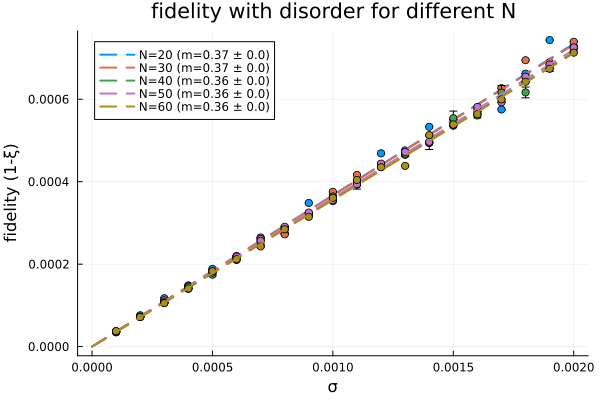

In [58]:
using ITensors, ITensorMPS, Plots
using Statistics, StatsBase, GLM, DataFrames

N_vals = 20:10:60
sigma_vals = vcat(0.0001:0.0001:0.002)
accuracies = [10^-16]

p_master = plot(title="fidelity with disorder for different N",
                xlabel="σ",
                ylabel="fidelity (1-ξ)",
                legend=:topleft)

for (i, N) in enumerate(N_vals)
    @info "Processing N = $N"

    avg_fids = Float64[]
    err_fids = Float64[]
    sig_vars = Float64[]

    for sigma in sigma_vals
        system_params = Dict{String,Any}(
            "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
            "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
        )
        fp_suffix = extract_filename_from_system_params(system_params)
        fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(sigma)_$(fp_suffix).hd5")

        cln_rns = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:all)
        dis_rns = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>sigma); load_psi=true, instance_selection=:all)

        if !isempty(cln_rns) && !isempty(dis_rns)
            fids = [infidelity(c.psi, d.psi) for (c, d) in zip(cln_rns, dis_rns)]

            push!(avg_fids, mean(fids))
            push!(err_fids, length(fids) > 1 ? sem(fids) : 0.0)
            push!(sig_vars, sigma)
        end
    end

    if length(avg_fids) > 1

        wts = [e > 0 ? 1/e^2 : 1.0 for e in err_fids]

        df = DataFrame(X = sig_vars, Y = avg_fids)
        model = lm(@formula(Y ~ 0 + X), df, wts=wts)

        gradient = coef(model)[1]
        grad_err = stderror(model)[1]

        label_str = "N=$N (m=$(round(gradient, digits=2)) ± $(round(grad_err, digits=2)))"

        scatter!(p_master, sig_vars, avg_fids, yerror=err_fids, label=false, color=i)

        plot!(p_master, x -> gradient * x, 0, maximum(sig_vars),
              label=label_str, lw=2, linestyle=:dash, color=i)
    end
end

display(p_master)
# savefig(p_master, "fidelity_scaling_N_sweep.png")

## Bounding the error

we have 
$$
\ket{\psi_{\sigma}} = \xi \ket{\psi_{0}} + (1-\xi) \ket{\psi_{r}}   
$$

define the truncation error from the residual state 
$$
\varepsilon^2 \propto \text{truncation error of } \ket{\psi_\text{res}} = \sum_{i}^{\chi} \lambda_i^2
$$

so we can work out total error for each state dep on $(N, \sigma)$ by finding $\ket{\psi_r}$ as we did earlier if we were to approximate it with the truncated state.

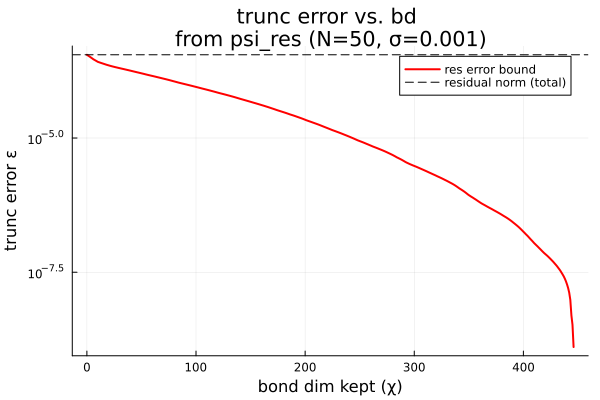

In [29]:
# lets do this with just 1 state (N=40, σ=0.002). We want to plot a graph of thrown away bond dimension Χ_r vs ε for the residual state.
# this way, we can see how the amount of bond dimension we remove gives us a bound on the error we should expect

N, σ = 50, 0.001
system_params = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
)
fp_suffix = extract_filename_from_system_params(system_params)
fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(σ)_$(fp_suffix).hd5")

psi_cln = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:latest)[1].psi
psi_dis = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=:latest)[1].psi

ξ = inner(psi_cln, psi_dis)
psi_res = get_psi_r(psi_cln, psi_dis; normalize=false)

spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)

max_chi = length(spec_res)
chis = 0:(max_chi - 1)
epsilons = [sqrt(sum(spec_res[k+1:end])) for k in chis]

p_trunc = plot(chis, epsilons,
               yscale=:log10,
               lw=2,
               lc=:red,
               title="trunc error vs. bd \nfrom psi_res (N=$N, σ=$σ)",
               xlabel="bond dim kept (χ)",
               ylabel="trunc error ε",
               label="res error bound")

res_norm = sqrt(1 - abs(ξ)^2)
hline!([res_norm], linestyle=:dash, lc=:black, label="residual norm (total)")

display(p_trunc)

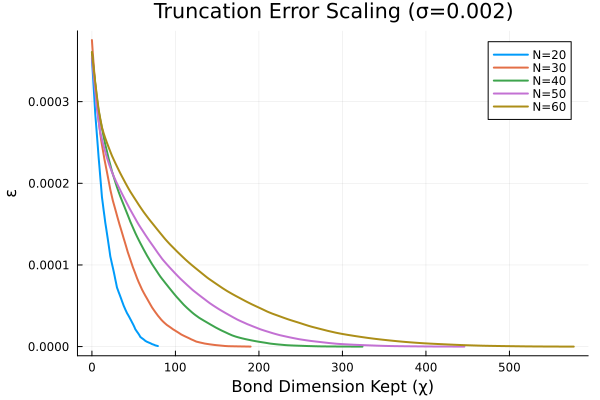

In [30]:
p_all_n = plot(title="Truncation Error Scaling (σ=0.002)",
                xlabel="Bond Dimension Kept (χ)",
               ylabel="ε", legend=:topright)

for (i, N) in enumerate([20, 30, 40, 50, 60])
    system_params = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
    )
    fp_suffix = extract_filename_from_system_params(system_params)
    fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(σ)_$(fp_suffix).hd5")

    psi_cln = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:latest)[1].psi
    psi_dis = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=:latest)[1].psi

    psi_res = get_psi_r(psi_cln, psi_dis; normalize=false)

    spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)

    max_chi = length(spec_res)
    epsilons = [sqrt(sum(spec_res[k+1:end])) for k in 0:max_chi-1]

    plot!(p_all_n, 0:max_chi-1, epsilons, label="N=$N", color=i, lw=2)
end

display(p_all_n)

N = 20: Extracted α = 0.11578
N = 30: Extracted α = 0.05202
N = 40: Extracted α = 0.03315
N = 50: Extracted α = 0.02144
N = 60: Extracted α = 0.01664


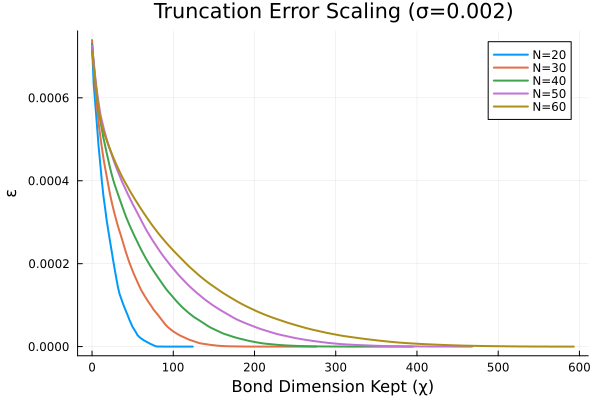

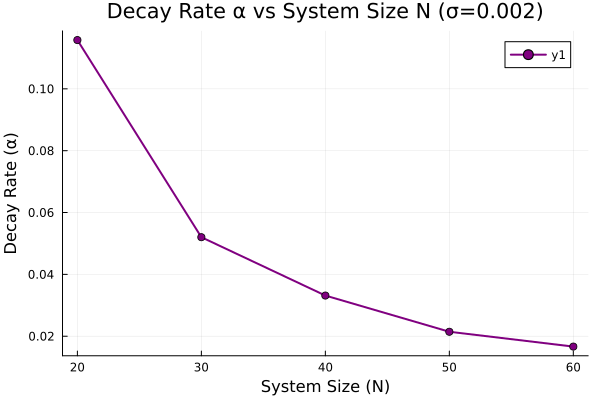

In [64]:
using LinearAlgebra # for the least-squares fit operator (\)
using Plots

p_all_n = plot(title="Truncation Error Scaling (σ=0.002)",
               xlabel="Bond Dimension Kept (χ)",
               ylabel="ε", legend=:topright)

# Arrays to store our extracted decay rates
Ns = [20, 30, 40, 50, 60]
alphas = Float64[]

σ = 0.002 # Fixed sigma for this first run

for (i, N) in enumerate(Ns)
    system_params = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
    )
    fp_suffix = extract_filename_from_system_params(system_params)
    fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(σ)_$(fp_suffix).hd5")

    psi_cln = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:latest)[1].psi
    psi_dis = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=:latest)[1].psi

    psi_res = get_psi_r(psi_cln, psi_dis; normalize=false)
    spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)

    max_chi = length(spec_res)
    epsilons = [sqrt(sum(spec_res[k+1:end])) for k in 0:max_chi-1]

    plot!(p_all_n, 0:max_chi-1, epsilons, label="N=$N", color=i, lw=2)

    # --- NEW: EXTRACT α(N) ---

    # 1. Filter out numerical noise/zeroes at the end of the spectrum
    valid_mask = epsilons .> 1e-12
    valid_indices = findall(valid_mask)

    if isempty(valid_indices)
        push!(alphas, NaN)
        continue
    end

   idx_start = max(maxlinkdim(psi_cln), valid_indices[1])
    idx_end = valid_indices[end]

    if idx_start < idx_end
        # Slice the epsilons directly using the valid indices
        eps_fit = epsilons[idx_start:idx_end]

        # Calculate the physical χ values corresponding to these indices
        # (index 1 corresponds to χ = 0)
        chi_fit = (idx_start:idx_end) .- 1

        # Linearize: y = mx + c  =>  ln(ε) = -α * χ + ln(A)
        x_data = Float64.(chi_fit)
        y_data = log.(eps_fit)

        # Least squares fit using the pseudo-inverse (\)
        X_matrix = hcat(x_data, ones(length(x_data)))
        coeffs = X_matrix \ y_data

        alpha = -coeffs[1] # The slope is -alpha
        push!(alphas, alpha)

        println("N = $N: Extracted α = $(round(alpha, digits=5))")
    else
        push!(alphas, NaN)
        println("N = $N: Could not fit (spectrum too short)")
    end
end

display(p_all_n)

# --- PLOT HOW α SCALES WITH N ---
p_alpha = plot(Ns, alphas, marker=:circle,
               title="Decay Rate α vs System Size N (σ=$σ)",
               xlabel="System Size (N)",
               ylabel="Decay Rate (α)",
            #    yscale=:log10,
               lw=2, color=:purple,
               grid=true)
display(p_alpha)

In [66]:
# 2. expoonential fi: ln(α) = ln(A) - b*N
x_exp = Float64.(Ns)
y_exp = log.(alphas)
X_matrix_exp = hcat(x_exp, ones(length(x_exp)))
coeffs_exp = X_matrix_exp \ y_exp
b_exp = -coeffs_exp[1]
A_exp = exp(coeffs_exp[2])

y_pred_exp = coeffs_exp[1] .* x_exp .+ coeffs_exp[2]
R2_exp = 1 - sum((y_exp .- y_pred_exp).^2) / sum((y_exp .- mean(y_exp)).^2)

println("A = $(round(A_exp, digits=5)), b = $(round(b_exp, digits=5))")
println("R² = $(round(R2_exp, digits=4))")

A = 0.25031, b = 0.04766
R² = 0.9602


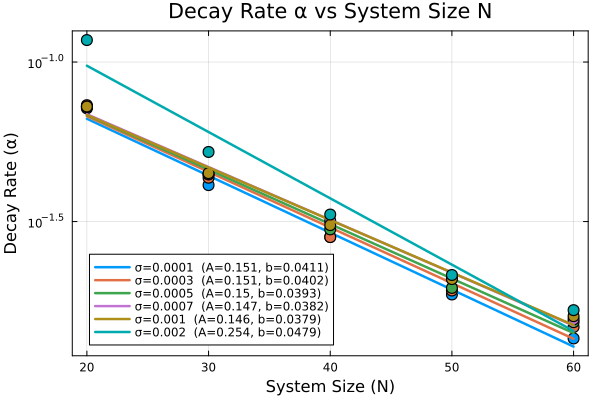

In [71]:
using LinearAlgebra
using Plots

# Define the parameters we want to scan
Ns = [20, 30, 40, 50, 60]
sigmas = [0.0001, 0.0003, 0.0005, 0.0007, 0.001, 0.002]

# Initialize the main plot
p_alpha_fits = plot(title="Decay Rate α vs System Size N",
                    xlabel="System Size (N)",
                    ylabel="Decay Rate (α)",
                    yaxis=:log10,
                    legend=:bottomleft,
                    grid=true,
                    framestyle=:box)

for (i, σ) in enumerate(sigmas)
    alphas = Float64[]
    valid_Ns = Int[]

    for N in Ns
        system_params = Dict{String,Any}(
            "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
            "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
        )
        fp_suffix = extract_filename_from_system_params(system_params)
        fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(σ)_$(fp_suffix).hd5")

        runs_cln = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:latest)
        runs_dis = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=:latest)

        if isempty(runs_cln) || isempty(runs_dis)
            continue
        end

        psi_cln = runs_cln[1].psi
        psi_dis = runs_dis[1].psi

        psi_res = get_psi_r(psi_cln, psi_dis; normalize=false)
        spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)

        max_chi = length(spec_res)
        epsilons = [sqrt(sum(spec_res[k+1:end])) for k in 0:max_chi-1]

        chi_c = maxlinkdim(psi_cln)

        valid_mask = epsilons .> 1e-12
        valid_indices = findall(valid_mask)

        if !isempty(valid_indices)
            idx_start = max(chi_c + 2, valid_indices[1])
            idx_end = valid_indices[end]

            if idx_start < idx_end
                eps_fit = epsilons[idx_start:idx_end]
                chi_fit = (idx_start:idx_end) .- 1

                x_data = Float64.(chi_fit)
                y_data = log.(eps_fit)

                X_matrix = hcat(x_data, ones(length(x_data)))
                coeffs = X_matrix \ y_data

                alpha = -coeffs[1]
                push!(alphas, alpha)
                push!(valid_Ns, N)
            end
        end
    end

    if length(valid_Ns) > 2
        x_fit = Float64.(valid_Ns)
        y_fit = log.(alphas)
        X_matrix_exp = hcat(x_fit, ones(length(x_fit)))
        coeffs_exp = X_matrix_exp \ y_fit

        b_exp = -coeffs_exp[1]
        A_exp = exp(coeffs_exp[2])

        N_smooth = range(minimum(valid_Ns), maximum(valid_Ns), length=100)
        alpha_smooth = A_exp .* exp.(-b_exp .* N_smooth)

        lbl = "σ=$σ  (A=$(round(A_exp, digits=3)), b=$(round(b_exp, digits=4)))"

        scatter!(p_alpha_fits, valid_Ns, alphas, color=i, label="", markersize=6, markerstrokewidth=1.5)
        plot!(p_alpha_fits, N_smooth, alpha_smooth, color=i, label=lbl, lw=2.5)
    end
end

display(p_alpha_fits)

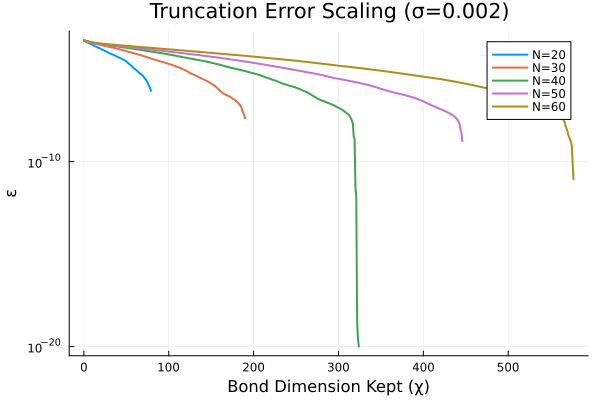

In [31]:
p_all_n = plot(title="Truncation Error Scaling (σ=0.002)",
                yscale=:log10,
                xlabel="Bond Dimension Kept (χ)",
               ylabel="ε", legend=:topright)

for (i, N) in enumerate([20, 30, 40, 50, 60])
    system_params = Dict{String,Any}(
    "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
    "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
    )
    fp_suffix = extract_filename_from_system_params(system_params)
    fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(σ)_$(fp_suffix).hd5")

    psi_cln = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:latest)[1].psi
    psi_dis = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=:latest)[1].psi

    psi_res = get_psi_r(psi_cln, psi_dis; normalize=false)

    spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)

    max_chi = length(spec_res)
    epsilons = [sqrt(sum(spec_res[k+1:end])) for k in 0:max_chi-1]

    plot!(p_all_n, 0:max_chi-1, epsilons, label="N=$N", color=i, lw=2)
end

display(p_all_n)

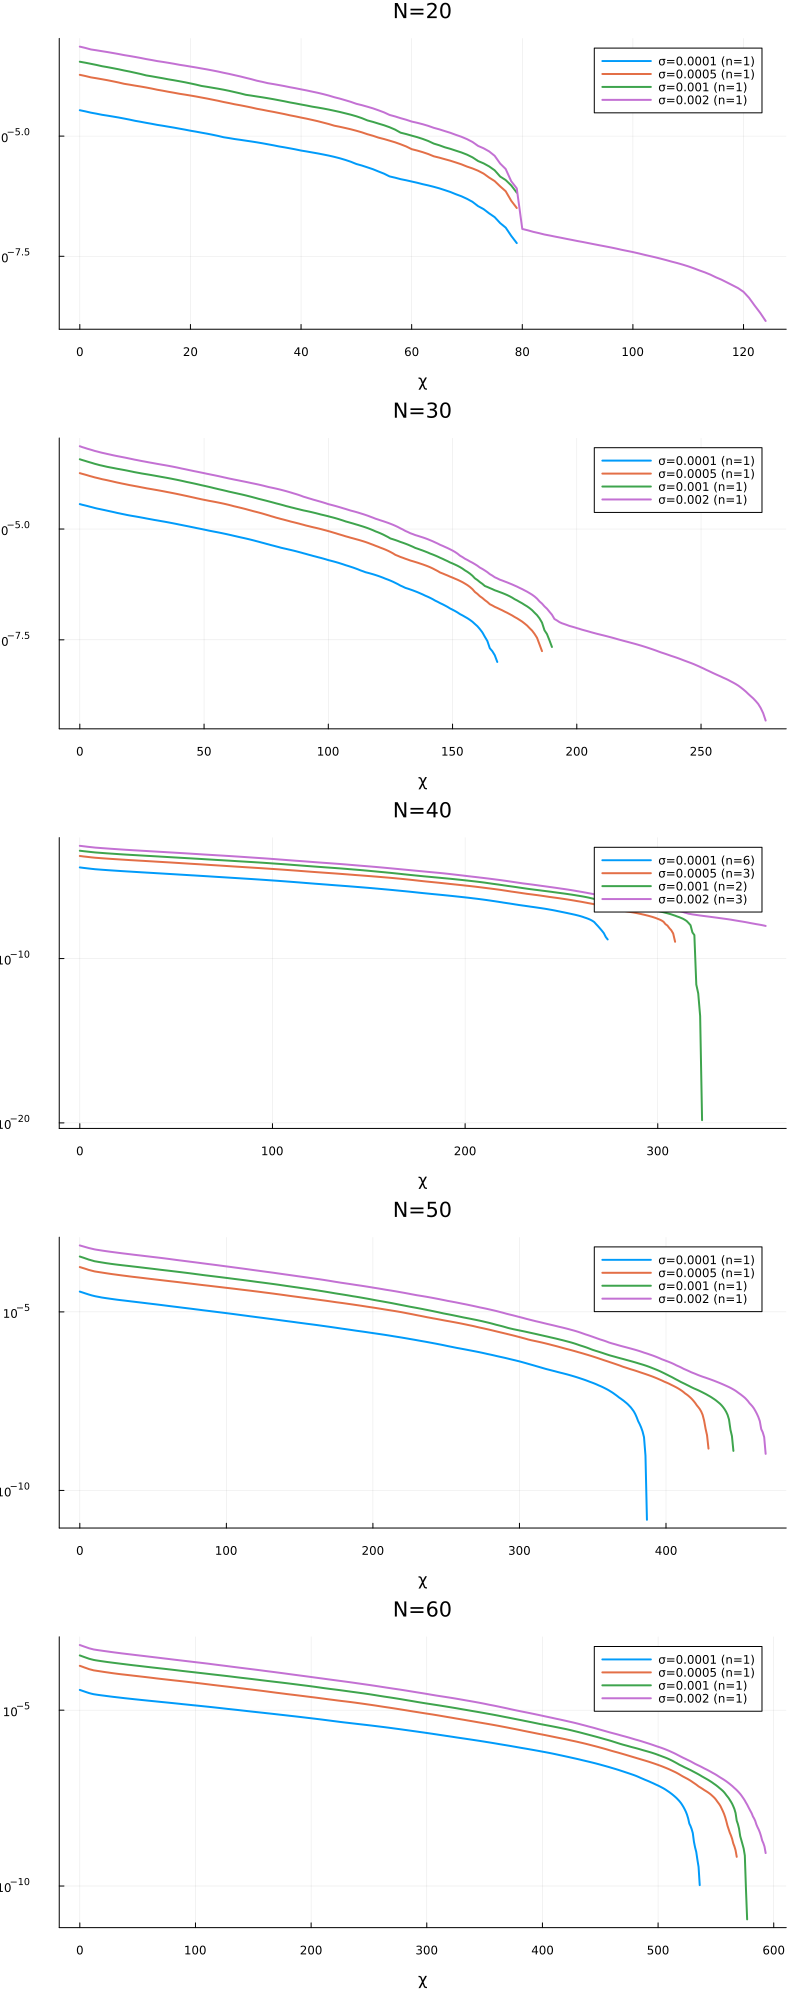

In [32]:
using ITensors, ITensorMPS, Plots, Statistics

N_vals = 20:10:60
sigma_vals = [0.0001, 0.0005, 0.001, 0.002]

plots = []

for N in N_vals
    p = plot(title="N=$N",
             yscale=:log10,
             xlabel="χ",
             ylabel="ε",
             legend=:topright,
             lw=2)

    for sigma in sigma_vals
        system_params = Dict{String,Any}(
            "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
            "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
        )
        fp_suffix = extract_filename_from_system_params(system_params)
        fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(sigma)_$(fp_suffix).hd5")

        cln_data = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:all)
        dis_data = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>sigma); load_psi=true, instance_selection=:all)

        if isempty(cln_data) || isempty(dis_data)
            continue
        end

        num_instances = min(length(cln_data), length(dis_data))
        epsilon_curves = []

        for i in 1:num_instances
            psi_cln = cln_data[i].psi
            psi_dis = dis_data[i].psi
            psi_res = get_psi_r(psi_cln, psi_dis; normalize=false)
            spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)

            max_chi = length(spec_res)
            epsilons = [sqrt(sum(spec_res[k+1:end])) for k in 0:max_chi-1]

            push!(epsilon_curves, epsilons)
        end

        # Average over instances
        min_length = minimum(length.(epsilon_curves))
        avg_epsilons = [mean([curve[i] for curve in epsilon_curves]) for i in 1:min_length]

        plot!(p, 0:min_length-1, avg_epsilons,
              label="σ=$sigma (n=$num_instances)",
              lw=2)
    end

    push!(plots, p)
end

plot(plots..., layout=(length(N_vals), 1), size=(800, 400*length(N_vals)))

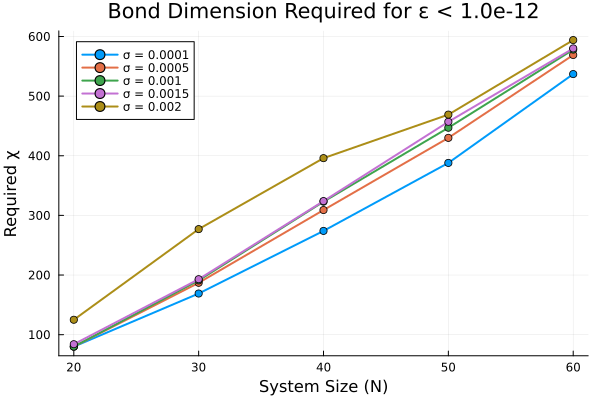

In [33]:
target_epsilon = 1e-12
N_vals = [20, 30, 40, 50, 60]
σs = [0.0001, 0.0005, 0.001, 0.0015, 0.002]
# σs = 0.0001:0.0001:0.002

pl = plot(title="Bond Dimension Required for ε < $target_epsilon",
          xlabel="System Size (N)",
          ylabel="Required χ",
          legend=:topleft,
          grid=true)

for σ in σs
    current_sigma_chis = Int[]

    for N in N_vals
        system_params = Dict{String,Any}(
            "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
            "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
        )

        fp_suffix = extract_filename_from_system_params(system_params)
        fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(σ)_$(fp_suffix).hd5")

        cln_runs = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:latest)
        dis_runs = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>σ); load_psi=true, instance_selection=:latest)

        if isempty(cln_runs) || isempty(dis_runs)
            @warn "Data missing for N=$N, σ=$σ"
            push!(current_sigma_chis, 0)
            continue
        end

        psi_cln = cln_runs[1].psi
        psi_dis = dis_runs[1].psi

        # don't normalise - gives better measure of Error
        # but scaling should be identical
        psi_res = get_psi_r(psi_cln, psi_dis; normalize=false)
        spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)

        max_chi = length(spec_res)
        epsilons = [sqrt(sum(spec_res[k+1:end])) for k in 0:max_chi-1]

        idx = findfirst(e -> e < target_epsilon, epsilons)

        # if no index is found (even keeping all is > target), use max_chi
        push!(current_sigma_chis, idx === nothing ? max_chi : idx)
    end

    plot!(pl, N_vals, current_sigma_chis,
          marker=:circle,
          label="σ = $σ",
          lw=2)
end

display(pl)

┌ Info: Processing column N = 20
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X33sZmlsZQ==.jl:13
┌ Info: Processing column N = 30
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X33sZmlsZQ==.jl:13
┌ Info: Processing column N = 40
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X33sZmlsZQ==.jl:13
┌ Info: Processing column N = 50
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X33sZmlsZQ==.jl:13
┌ Info: Processing column N = 60
└ @ Main /Users/jamesneville-rolfe/dev/uni/msciproject/programs/perturb/jl_notebook_cell_df34fa98e69747e1a8f8a730347b8e2f_X33sZmlsZQ==.jl:13


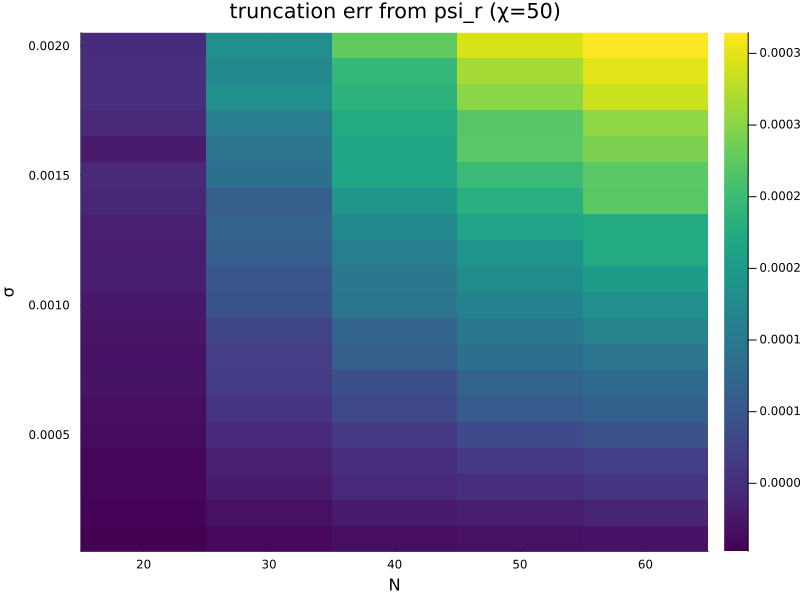

In [34]:
using ITensors, ITensorMPS, Plots, Statistics


N_vals = 20:10:60
sigma_vals = 0.0001:0.0001:0.002
target_chi = 50

Z_matrix = zeros(length(sigma_vals), length(N_vals))

safe_log10(x) = x > 1e-16 ? log10(x) : -16.0

for (n_idx, N) in enumerate(N_vals)
    @info "Processing column N = $N"
    for (s_idx, sigma) in enumerate(sigma_vals)

        system_params = Dict{String,Any}(
            "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
            "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
        )
        fp_suffix = extract_filename_from_system_params(system_params)
        fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(sigma)_$(fp_suffix).hd5")

        cln_data = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:latest)
        dis_data = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>sigma); load_psi=true, instance_selection=:latest)

        if isempty(cln_data) || isempty(dis_data)
            Z_matrix[s_idx, n_idx] = NaN
            continue
        end

        psi_cln = cln_data[1].psi
        psi_dis = dis_data[1].psi

        psi_res = get_psi_r(psi_cln, psi_dis; normalize=false)

        spec_res = get_squared_sorted_schmidt_spectrum_from_mps(psi_res)

        if length(spec_res) > target_chi
            eps_sq = sum(spec_res[target_chi+1:end])
            epsilon = sqrt(max(0.0, eps_sq))
        else
            epsilon = 0.0
        end

        Z_matrix[s_idx, n_idx] = epsilon
    end
end

heatmap(N_vals, sigma_vals, Z_matrix,
        title="truncation err from psi_r (χ=$target_chi)",
        xlabel="N",
        ylabel="σ",
        clabel="epsilon",
        color=:viridis,
        size=(800, 600))

# Renyi entropy scaling of the residual state

In [79]:
function calculate_renyi_entropy_from_spectrum(spec::Vector{Float64}, α::Float64)
    λ_nonzero = filter(x -> x > 1e-16, spec)
    # for small alpha, transition to vn
    if abs(α - 1.0) < 1e-10
        # von Neumann
        return -sum(λ_i * log(λ_i) for λ_i in λ_nonzero)
    else
        # renyi
        return log(sum(λ_nonzero.^α)) / (1 - α)
    end
end

calculate_renyi_entropy_from_spectrum (generic function with 1 method)

In [86]:
using LsqFit

function plot_renyi(N_vals, sigma_vals, α)
    system_params = Dict{String,Any}(
        "J" => -1.0, "Δ" => -1.0, "μ" => 1.0,
        "NUM_SWEEPS" => 10, "MAX_BOND_DIM" => 1000, "ACC" => 10^-16
    )

    p = plot(title="ren ent (alpha=$α) vs N",
            xlabel="N",
            ylabel="S_$α",
            legend=:bottomright,
            lw=2,
            marker=:circle,
            markersize=4)

    for (color_idx, sigma) in enumerate(sigma_vals)
        N_list = Int[]
        S_list = Float64[]
        S_err_list = Float64[]

        for N in N_vals
            fp_suffix = extract_filename_from_system_params(system_params)
            fp = joinpath(@__DIR__, "../../data/storage/perturb_sigma_$(sigma)_$(fp_suffix).hd5")

            cln_data = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>0.00); load_psi=true, instance_selection=:all)
            dis_data = find_runs_by_params(fp, Dict{String, Any}("N"=>N, "σ"=>sigma); load_psi=true, instance_selection=:all)

            if isempty(cln_data) || isempty(dis_data)
                @warn "Missing data for N=$N, σ=$sigma"
                continue
            end

            num_instances = min(length(cln_data), length(dis_data))
            entropies = Float64[]

            for i in 1:num_instances
                psi_cln = cln_data[i].psi
                psi_dis = dis_data[i].psi
                psi_r = get_psi_r(psi_cln, psi_dis; normalize=true)

                spec = get_squared_sorted_schmidt_spectrum_from_mps(psi_r)
                S = calculate_renyi_entropy_from_spectrum(spec, α)

                push!(entropies, S)
            end

            avg_S = mean(entropies)
            err_S = length(entropies) > 1 ? std(entropies) / sqrt(length(entropies)) : 0.0

            push!(N_list, N)
            push!(S_list, avg_S)
            push!(S_err_list, err_S)
        end

        if length(N_list) < 2
            continue
        end

        # fit power law: S = A * N^κ
        model(x, p) = p[1] .* x.^p[2]  # p[1] = A, p[2] = κ
        p0 = [1.0, 1.0]
        weights = [err > 0 ? 1/err^2 : 1.0 for err in S_err_list] # weight by error (or if none, just set to 1.0)

        try
            fit_result = curve_fit(model, Float64.(N_list), S_list, weights, p0)
            A, κ = coef(fit_result)


            errors = stderror(fit_result)
            κ_err = errors[2]

            # points
            scatter!(p, N_list, S_list,
                    yerror=S_err_list,
                    label="σ=$sigma (κ=$(round(κ, digits=3))±$(round(κ_err, digits=3)))",
                    color=color_idx,
                    markersize=4)

            # fit line
            N_fit = range(minimum(N_list), maximum(N_list), length=100)
            S_fit = model(N_fit, [A, κ])
            plot!(p, N_fit, S_fit,
                  label=false,
                  color=color_idx,
                  linestyle=:dash,
                  lw=2)

        catch e
            @warn "Fit failed for σ=$sigma: $e"
            # data w/o fit
            scatter!(p, N_list, S_list,
                    yerror=S_err_list,
                    label="σ=$sigma (fit failed)",
                    color=color_idx,
                    markersize=4)
        end
    end

    display(p)
end

plot_renyi (generic function with 1 method)

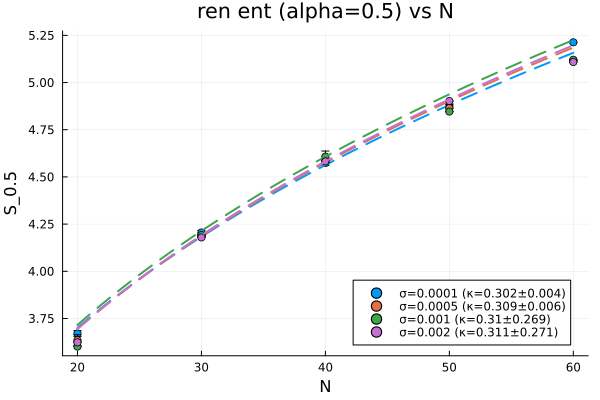

In [81]:
N_vals = 20:10:60
sigma_vals = [0.0001, 0.0005, 0.001, 0.002]

plot_renyi(N_vals, sigma_vals, 0.5)

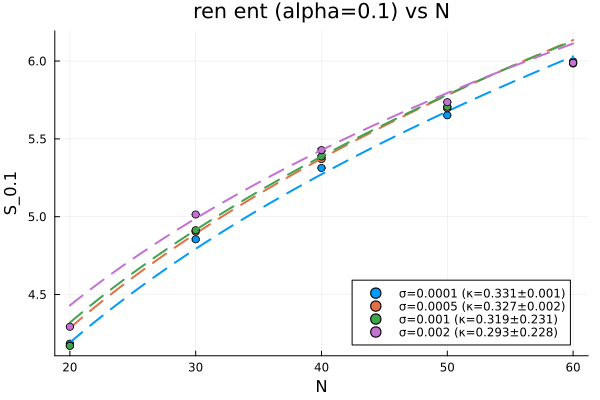

In [82]:
plot_renyi(N_vals, sigma_vals, 0.1)

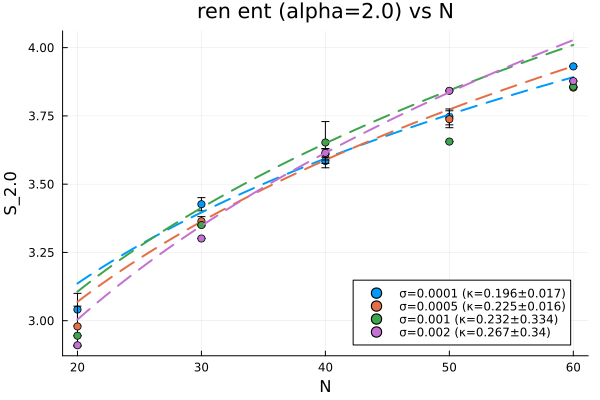

In [88]:
plot_renyi(N_vals, sigma_vals, 2.0)

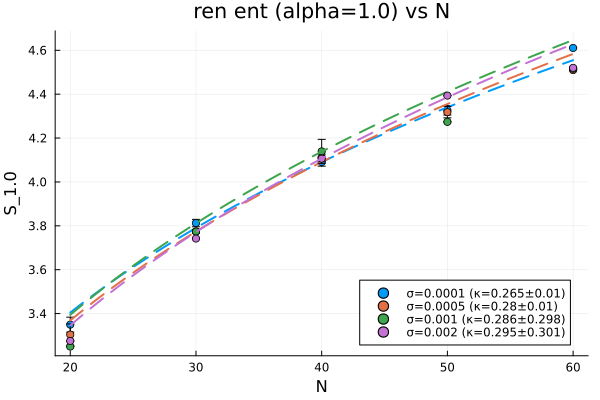

In [87]:
plot_renyi(N_vals, sigma_vals, 1.0) # vn ent

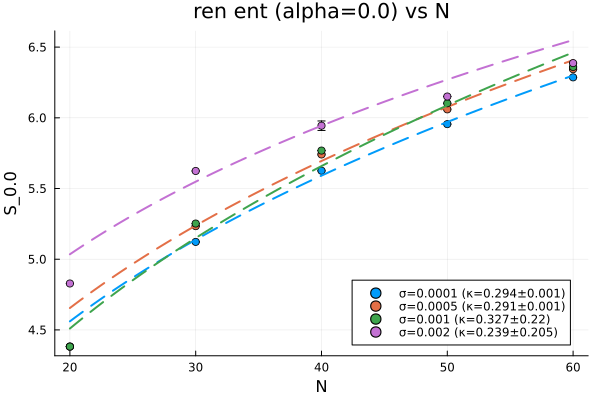

In [85]:
plot_renyi(N_vals, sigma_vals, 0.0)